# **Question Answer Matching System using Bi-Directional LSTM Siamese Network**

### **Project Objective**

The objective of this project is to build a **question-answer / question-question semantic matching system** using a **Bi-Directional LSTM Siamese Network** to determine whether two questions are duplicates or semantically equivalent. The goal is to learn robust sequence representations for both input questions and compare them through similarity-aware layers so that the model can identify meaning overlap even when the wording differs. This project demonstrates how BiLSTM-based Siamese architectures can be used in practical NLP systems such as duplicate question detection, FAQ consolidation, community forum de-duplication, and semantic search pipelines.

### **Dataset Used**

The dataset used in this project is based on the **Quora Question Pairs** dataset, available at:

**Dataset Link:** https://www.kaggle.com/c/quora-question-pairs

This dataset typically contains pairs of user questions along with a binary label indicating whether the two questions are duplicates. Each record generally includes:

- **question1** → first question in the pair  
- **question2** → second question in the pair  
- **is_duplicate** → target label indicating semantic equivalence  

In this notebook, the dataset is used as the supervised corpus for pairwise semantic matching. The workflow includes:

- loading and inspecting paired question records  
- cleaning and normalizing question text  
- studying duplicate vs non-duplicate class balance  
- tokenizing both question streams with a shared vocabulary  
- converting text into padded sequences  
- training a **BiLSTM Siamese model** for semantic similarity classification  
- evaluating the system with **accuracy, precision, recall, F1-score, confusion matrix, and confidence-based analysis**  
- visualizing similarity outputs and duplicate detection behavior  
- providing inference utilities and an optional deployment demo  

The dataset is especially suitable for this project because it reflects a real-world NLP setting in which semantic equivalence matters more than exact word overlap. This makes it a strong benchmark for context-sensitive sequence modeling.

### **Project Summary**

This project develops an end-to-end **semantic similarity classification pipeline** using a **BiLSTM Siamese Network**. The notebook begins by loading and profiling the question pair dataset, inspecting pair counts, label distribution, and question length patterns. It then cleans the question text, tokenizes both question streams with a shared tokenizer, pads sequences, and prepares train, validation, and test splits.

The core model uses a shared embedding layer and a shared **BiLSTM encoder**, which processes each question in both forward and backward directions. This shared encoder generates contextual sequence embeddings for both question inputs. The two encoded outputs are then compared using element-wise difference, element-wise multiplication, and dense similarity layers, allowing the model to learn whether the questions are semantically equivalent.

The project also includes practical evaluation beyond simple accuracy. It covers weighted precision, recall, F1-score, confusion matrix review, confidence-based prediction analysis, duplicate-vs-nonduplicate error inspection, and side-by-side sample outputs. It also includes pairwise similarity visualization and inference utilities that make the notebook closer to a real production-style duplicate detection workflow.

The final notebook includes model saving and reload validation, prediction export, and an optional demo section. As a result, it serves as both a strong portfolio project and a realistic demonstration of Siamese BiLSTM-based NLP similarity modeling.

### **Key Highlights**

- Built a **question duplicate detection system** using a **Bi-Directional LSTM Siamese Network**.
- Used the **Quora Question Pairs** dataset as the supervised corpus for semantic similarity learning.
- Performed detailed **dataset exploration**, including class balance and question length analysis.
- Implemented **text cleaning, tokenization, vocabulary building, and shared sequence preprocessing**.
- Built a **shared BiLSTM encoder** to generate contextual representations for both questions.
- Used **difference and interaction-based similarity features** to classify duplicate vs non-duplicate pairs.
- Evaluated the model using **accuracy, precision, recall, F1-score, confusion matrix, and confidence analysis**.
- Added **sample outputs**, **error analysis**, and **pairwise similarity inspection**.
- Included **model save/reload validation** and an optional **deployment demo** section.
- Preserved a modular workflow so the project can be extended into FAQ matching, search deduplication, or forum intelligence systems.


### **Install Required Libraries**

In [1]:
!pip -q install -U pandas numpy matplotlib scikit-learn nltk ipywidgets tensorflow keras

### **Import Core Libraries**

In [2]:
import os
import gc
import re
import json
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    GlobalMaxPooling1D,
    Lambda,
    Concatenate,
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

### **Notebook Display Settings**

In [3]:
pd.set_option("display.max_colwidth", 240)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

### **Set Reproducibility Seed**

In [4]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


### **Create Project Folders**

In [5]:
PROJECT_DIR = Path("./question_answer_matching_bilstm_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "saved_model"
PRED_DIR = PROJECT_DIR / "predictions"

for folder in [PROJECT_DIR, ARTIFACT_DIR, MODEL_DIR, PRED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


### **Define Project Configuration**

In [6]:
DATA_ROOT = Path("./quora_question_pairs_data")
DATA_FILE = DATA_ROOT / "quora_question_pairs.csv"

MAX_VOCAB_SIZE = 40000
MAX_SEQ_LEN = 40
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.30
BATCH_SIZE = 64
EPOCHS = 5

print("Configuration ready.")

Configuration ready.


### **State the Real-World Problem**

In [7]:
problem_statement = '''
Duplicate question detection is important in search engines, technical forums, and knowledge communities.
If semantically identical questions are not detected, content becomes fragmented and retrieval quality suffers.
This project addresses that problem by using a BiLSTM Siamese network to detect semantic similarity between question pairs.
'''
print(problem_statement)


Duplicate question detection is important in search engines, technical forums, and knowledge communities.
If semantically identical questions are not detected, content becomes fragmented and retrieval quality suffers.
This project addresses that problem by using a BiLSTM Siamese network to detect semantic similarity between question pairs.



### **Show Expected Dataset Structure**

In [8]:
expected_structure = '''
quora_question_pairs_data/
└── quora_question_pairs.csv

Common columns may include:
- question1
- question2
- is_duplicate
'''
print(expected_structure)


quora_question_pairs_data/
└── quora_question_pairs.csv

Common columns may include:
- question1
- question2
- is_duplicate



### **Create a Small Placeholder Dataset if Missing**

In [9]:
if not DATA_FILE.exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    sample_df = pd.DataFrame({
        "question1": [
            "How can I learn python quickly?",
            "What is the best way to study machine learning?",
            "How do I lose weight fast?",
            "What causes chest pain after exercise?",
            "How to improve English speaking skills?",
            "What is deep learning?",
            "How can I reduce belly fat?",
            "What are symptoms of heart attack?",
            "How do I become fluent in English?",
            "Explain neural networks in simple words."
        ],
        "question2": [
            "What is the fastest way to learn python?",
            "How should I start learning machine learning effectively?",
            "How can I lose body weight quickly?",
            "Why do I get chest pain after working out?",
            "How can I speak English fluently?",
            "Can you explain deep learning?",
            "What is the best way to reduce stomach fat?",
            "What are the warning signs of a heart attack?",
            "Tips to become fluent in spoken English?",
            "What are neural networks in easy language?"
        ],
        "is_duplicate": [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
    })

    extra_neg = pd.DataFrame({
        "question1": [
            "How can I learn python quickly?",
            "What is deep learning?",
            "How to improve English speaking skills?",
            "What causes chest pain after exercise?",
            "How do I lose weight fast?"
        ],
        "question2": [
            "What is the capital of France?",
            "How to cook pasta at home?",
            "Best camera for wildlife photography?",
            "How to become a software engineer?",
            "What is blockchain technology?"
        ],
        "is_duplicate": [0, 0, 0, 0, 0]
    })

    sample_df = pd.concat([sample_df, extra_neg], axis=0).reset_index(drop=True)
    sample_df.to_csv(DATA_FILE, index=False)
    print("Created a placeholder dataset for notebook structure.")
else:
    print("Dataset file already exists.")

Dataset file already exists.


### **Load the Question Pair Dataset**

In [10]:
df = pd.read_csv(DATA_FILE)
print(df.shape)
df.head()

(15, 3)


,question1,question2,is_duplicate
0,How can I learn python quickly?,What is the fastest way to learn python?,1
1,What is the best way to study machine learning?,How should I start learning machine learning effectively?,1
2,How do I lose weight fast?,How can I lose body weight quickly?,1
3,What causes chest pain after exercise?,Why do I get chest pain after working out?,1
4,How to improve English speaking skills?,How can I speak English fluently?,1


### **Inspect Dataset Columns**

In [11]:
df.columns.tolist()

['question1', 'question2', 'is_duplicate']

### **Rename Columns to Standard Names**

In [12]:
column_map = {}
for col in df.columns:
    lower_col = col.lower()
    if "question1" in lower_col or "q1" == lower_col:
        column_map[col] = "question1"
    elif "question2" in lower_col or "q2" == lower_col:
        column_map[col] = "question2"
    elif "duplicate" in lower_col or "label" in lower_col or "target" in lower_col:
        column_map[col] = "is_duplicate"

df = df.rename(columns=column_map)
df.head()

,question1,question2,is_duplicate
0,How can I learn python quickly?,What is the fastest way to learn python?,1
1,What is the best way to study machine learning?,How should I start learning machine learning effectively?,1
2,How do I lose weight fast?,How can I lose body weight quickly?,1
3,What causes chest pain after exercise?,Why do I get chest pain after working out?,1
4,How to improve English speaking skills?,How can I speak English fluently?,1


### **Check Missing Values**

In [13]:
df.isna().sum()

question1       0
question2       0
is_duplicate    0
dtype: int64

### **Drop Missing Question Rows**

In [14]:
df = df.dropna(subset=["question1", "question2", "is_duplicate"]).reset_index(drop=True)
print(df.shape)

(15, 3)


### **Inspect Duplicate Label Distribution**

In [15]:
df["is_duplicate"].value_counts()

is_duplicate
1    10
0     5
Name: count, dtype: int64

### **Plot Duplicate Label Distribution**

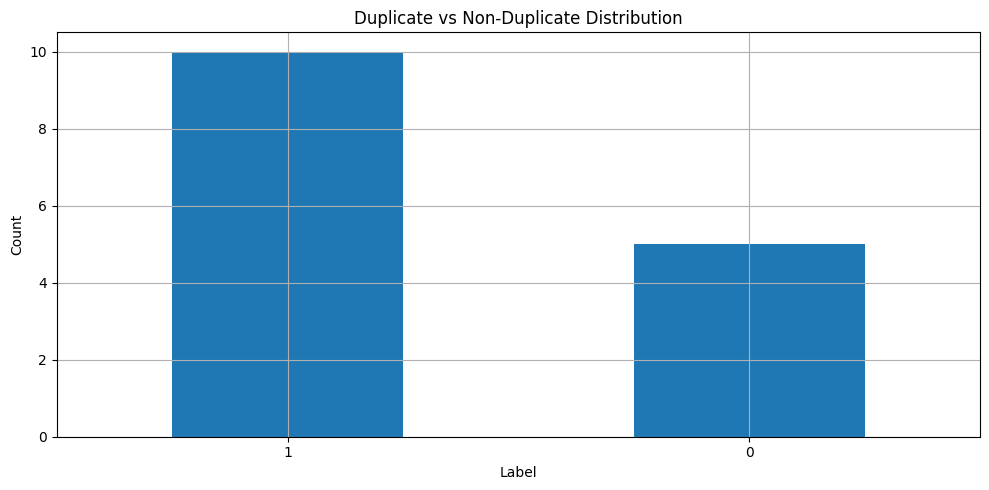

In [16]:
df["is_duplicate"].value_counts().plot(kind="bar")
plt.title("Duplicate vs Non-Duplicate Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### **Create Question Length Features for Question1**

In [17]:
df["q1_char_len"] = df["question1"].astype(str).str.len()
df["q1_word_len"] = df["question1"].astype(str).str.split().str.len()
df[["q1_char_len", "q1_word_len"]].describe().T

,count,mean,std,min,25%,50%,75%,max
q1_char_len,15.0,32.933333,7.333550,22.0,26.5,34.0,38.5,47.0
q1_word_len,15.0,6.000000,1.133893,4.0,6.0,6.0,6.0,9.0


### **Create Question Length Features for Question2**

In [18]:
df["q2_char_len"] = df["question2"].astype(str).str.len()
df["q2_word_len"] = df["question2"].astype(str).str.split().str.len()
df[["q2_char_len", "q2_word_len"]].describe().T

,count,mean,std,min,25%,50%,75%,max
q2_char_len,15.0,37.6,7.835815,26.0,31.5,37.0,42.0,57.0
q2_word_len,15.0,6.8,1.567528,4.0,6.0,7.0,8.0,9.0


### **Plot Question1 Word Length Distribution**

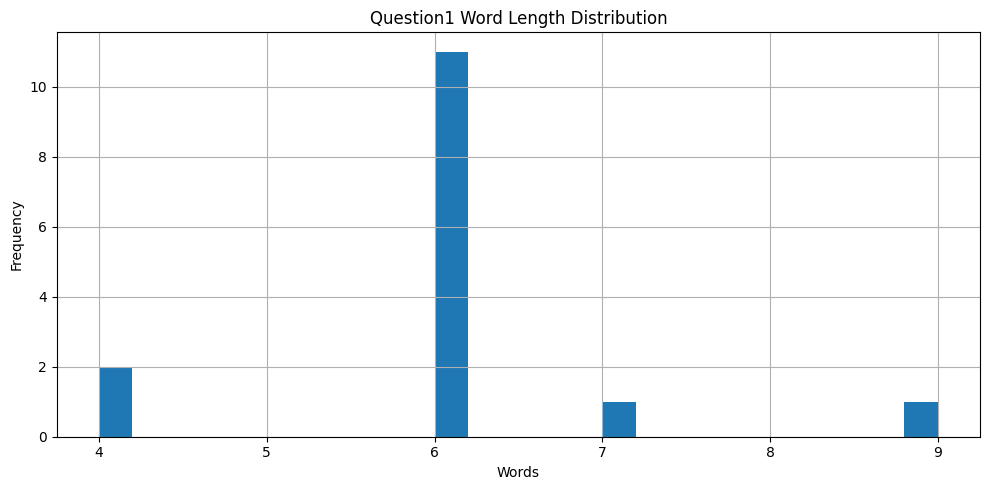

In [19]:
df["q1_word_len"].hist(bins=25)
plt.title("Question1 Word Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Plot Question2 Word Length Distribution**

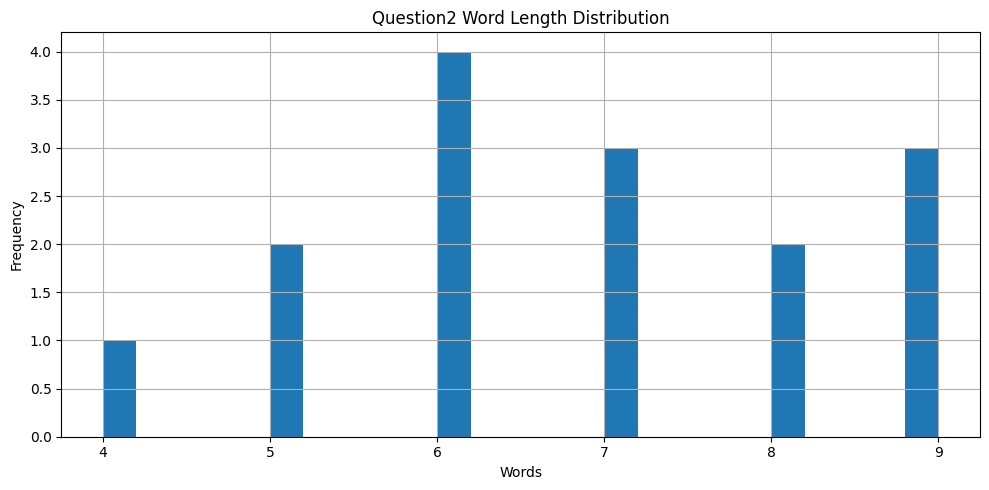

In [20]:
df["q2_word_len"].hist(bins=25)
plt.title("Question2 Word Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Display Random Question Pair Samples**

In [21]:
df.sample(min(5, len(df)), random_state=SEED)[["question1", "question2", "is_duplicate"]]

,question1,question2,is_duplicate
9,Explain neural networks in simple words.,What are neural networks in easy language?,1
11,What is deep learning?,How to cook pasta at home?,0
0,How can I learn python quickly?,What is the fastest way to learn python?,1
13,What causes chest pain after exercise?,How to become a software engineer?,0
5,What is deep learning?,Can you explain deep learning?,1


### **Define Text Cleaning Function**

In [22]:
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

### **Clean Question Text**

In [23]:
df["q1_clean"] = df["question1"].apply(clean_text)
df["q2_clean"] = df["question2"].apply(clean_text)
df[["question1", "q1_clean", "question2", "q2_clean"]].head(3)

,question1,q1_clean,question2,q2_clean
0,How can I learn python quickly?,how can i learn python quickly,What is the fastest way to learn python?,what is the fastest way to learn python
1,What is the best way to study machine learning?,what is the best way to study machine learning,How should I start learning machine learning effectively?,how should i start learning machine learning effectively
2,How do I lose weight fast?,how do i lose weight fast,How can I lose body weight quickly?,how can i lose body weight quickly


### **Estimate Combined Vocabulary Size**

In [24]:
all_tokens = " ".join(df["q1_clean"].tolist() + df["q2_clean"].tolist()).split()
vocab_size_est = len(set(all_tokens))
print("Estimated vocabulary size:", vocab_size_est)

Estimated vocabulary size: 79


### **Inspect Most Common Tokens**

In [25]:
pd.DataFrame(Counter(all_tokens).most_common(25), columns=["token", "count"])

,token,count
0,how,13
1,what,12
2,i,10
3,to,8
4,is,7
5,can,6
6,learning,6
7,the,5
8,english,5
9,do,4


### **Initialize Shared Tokenizer**

In [26]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["q1_clean"].tolist() + df["q2_clean"].tolist())
print("Tokenizer fitted successfully.")

Tokenizer fitted successfully.


### **Inspect Vocabulary Size after Tokenization**

In [27]:
vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
print("Vocabulary size used:", vocab_size)

Vocabulary size used: 81


### **Convert Questions to Sequences**

In [28]:
df["q1_seq"] = tokenizer.texts_to_sequences(df["q1_clean"].tolist())
df["q2_seq"] = tokenizer.texts_to_sequences(df["q2_clean"].tolist())
df[["q1_seq", "q2_seq"]].head(2)

,q1_seq,q2_seq
0,"[2, 7, 4, 13, 14, 15]","[3, 6, 9, 48, 17, 5, 13, 14]"
1,"[3, 6, 9, 16, 17, 5, 43, 27, 8]","[2, 49, 4, 50, 8, 27, 8, 51]"


### **Analyze Sequence Lengths for Question1**

In [29]:
q1_seq_lengths = df["q1_seq"].apply(len)
pd.Series(q1_seq_lengths).describe()

count    15.000000
mean      6.000000
std       1.133893
min       4.000000
25%       6.000000
50%       6.000000
75%       6.000000
max       9.000000
Name: q1_seq, dtype: float64

### **Analyze Sequence Lengths for Question2**

In [30]:
q2_seq_lengths = df["q2_seq"].apply(len)
pd.Series(q2_seq_lengths).describe()

count    15.000000
mean      6.800000
std       1.567528
min       4.000000
25%       6.000000
50%       7.000000
75%       8.000000
max       9.000000
Name: q2_seq, dtype: float64

### **Plot Question1 Sequence Length Distribution**

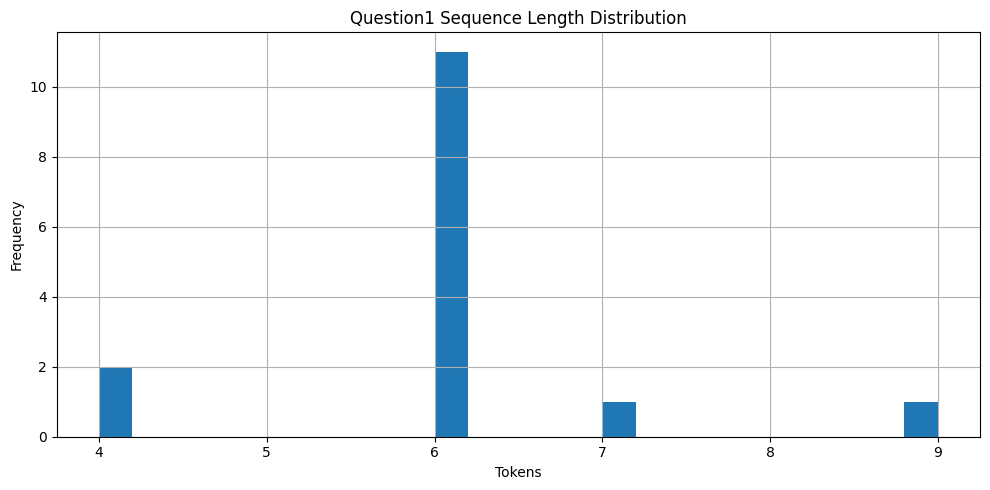

In [31]:
pd.Series(q1_seq_lengths).hist(bins=25)
plt.title("Question1 Sequence Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Plot Question2 Sequence Length Distribution**

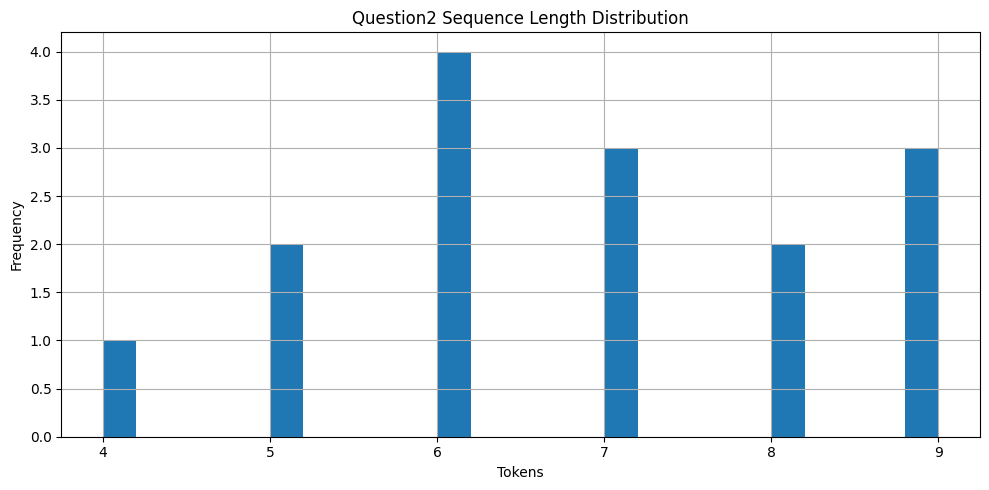

In [32]:
pd.Series(q2_seq_lengths).hist(bins=25)
plt.title("Question2 Sequence Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Pad Question1 Sequences**

In [33]:
X_q1 = pad_sequences(
    df["q1_seq"].tolist(),
    maxlen=MAX_SEQ_LEN,
    padding="post",
    truncating="post"
)
X_q1.shape

(15, 40)

### **Pad Question2 Sequences**

In [34]:
X_q2 = pad_sequences(
    df["q2_seq"].tolist(),
    maxlen=MAX_SEQ_LEN,
    padding="post",
    truncating="post"
)
X_q2.shape

(15, 40)

### **Create Label Array**

In [35]:
y = df["is_duplicate"].astype(int).values
y[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

### **Split into Train and Temp Sets**

In [36]:
X_q1_train, X_q1_temp, X_q2_train, X_q2_temp, y_train, y_temp = train_test_split(
    X_q1,
    X_q2,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

print(X_q1_train.shape, X_q1_temp.shape)

(10, 40) (5, 40)


### **Split Temp into Validation and Test Sets**

In [37]:
X_q1_val, X_q1_test, X_q2_val, X_q2_test, y_val, y_test = train_test_split(
    X_q1_temp,
    X_q2_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(X_q1_val.shape, X_q1_test.shape)

(2, 40) (3, 40)


### **Create Metadata DataFrames for Validation and Test Analysis**

In [38]:
train_meta_df, temp_meta_df = train_test_split(
    df.reset_index(drop=True),
    test_size=0.30,
    random_state=SEED,
    stratify=df["is_duplicate"]
)

val_meta_df, test_meta_df = train_test_split(
    temp_meta_df.reset_index(drop=True),
    test_size=0.50,
    random_state=SEED,
    stratify=temp_meta_df["is_duplicate"]
)

val_meta_df = val_meta_df.reset_index(drop=True)
test_meta_df = test_meta_df.reset_index(drop=True)

print(val_meta_df.shape, test_meta_df.shape)

(2, 11) (3, 11)


### **Define Shared BiLSTM Encoder**

In [39]:
def build_shared_encoder(max_len, vocab_size, embedding_dim, lstm_units, dropout_rate):
    text_input = Input(shape=(max_len,), name="question_input")
    x = Embedding(vocab_size, embedding_dim, name="embedding")(text_input)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True), name="bilstm")(x)
    x = GlobalMaxPooling1D(name="pooling")(x)
    x = Dropout(dropout_rate, name="dropout")(x)
    x = Dense(128, activation="relu", name="projection")(x)
    return Model(text_input, x, name="shared_encoder")

### **Create Shared Encoder Model**

In [40]:
shared_encoder = build_shared_encoder(
    MAX_SEQ_LEN,
    vocab_size,
    EMBEDDING_DIM,
    LSTM_UNITS,
    DROPOUT_RATE
)

shared_encoder.summary()

Model: "shared_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ question_input (InputLayer)          │ (None, 40)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 40, 128)             │          10,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm (Bidirectional)               │ (None, 40, 128)             │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pooling (GlobalMaxPooling1D)         │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ projection (Dense)                   │ (None, 128)                 │          16,512 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 125,696 (491.00 KB)

 Trainable params: 125,696 (491.00 KB)

 Non-trainable params: 0 (0.00 B)

### **Create Siamese Inputs**

In [41]:
q1_input = Input(shape=(MAX_SEQ_LEN,), name="q1_input")
q2_input = Input(shape=(MAX_SEQ_LEN,), name="q2_input")

q1_encoded = shared_encoder(q1_input)
q2_encoded = shared_encoder(q2_input)

q1_input, q2_input, q1_encoded, q2_encoded

(<KerasTensor shape=(None, 40), dtype=float32, sparse=False, ragged=False, name=q1_input>,
 <KerasTensor shape=(None, 40), dtype=float32, sparse=False, ragged=False, name=q2_input>,
 <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_5>,
 <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_6>)

### **Create Similarity Interaction Features**

In [42]:
@tf.keras.utils.register_keras_serializable(package="Custom")
def abs_diff_fn(tensors):
    return tf.abs(tensors[0] - tensors[1])

@tf.keras.utils.register_keras_serializable(package="Custom")
def multiply_fn(tensors):
    return tensors[0] * tensors[1]

def pairwise_output_shape(input_shapes):
    return input_shapes[0]

diff = Lambda(
    abs_diff_fn,
    output_shape=pairwise_output_shape,
    name="absolute_difference"
)([q1_encoded, q2_encoded])

mul = Lambda(
    multiply_fn,
    output_shape=pairwise_output_shape,
    name="elementwise_product"
)([q1_encoded, q2_encoded])

### **Concatenate Matching Features**

In [43]:
merged = Concatenate(name="merged_features")([q1_encoded, q2_encoded, diff, mul])
merged

<KerasTensor shape=(None, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_9>

### **Add Dense Similarity Layers**

In [44]:
x = Dense(128, activation="relu", name="dense_1")(merged)
x = Dropout(0.30, name="dropout_1")(x)
x = Dense(64, activation="relu", name="dense_2")(x)
x = Dropout(0.20, name="dropout_2")(x)
output = Dense(1, activation="sigmoid", name="duplicate_probability")(x)

output

<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_14>

### **Build the Full Siamese BiLSTM Model**

In [45]:
model = Model(inputs=[q1_input, q2_input], outputs=output, name="quora_duplicate_bilstm_siamese")
model.summary()

Model: "quora_duplicate_bilstm_siamese"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ q1_input (InputLayer)         │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ q2_input (InputLayer)         │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_encoder (Functional)   │ (None, 128)               │         125,696 │ q1_input[0][0],            │
│                               │                           │                 │ q2_input[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ absolute_difference (Lambda)  │ (None, 128)               │               0 │ shared_encoder[0][0],      │
│                               │                           │                 │ shared_encoder[1][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ elementwise_product (Lambda)  │ (None, 128)               │               0 │ shared_encoder[0][0],      │
│                               │                           │                 │ shared_encoder[1][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ merged_features (Concatenate) │ (None, 512)               │               0 │ shared_encoder[0][0],      │
│                               │                           │                 │ shared_encoder[1][0],      │
│                               │                           │                 │ absolute_difference[0][0], │
│                               │                           │                 │ elementwise_product[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 128)               │          65,664 │ merged_features[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 128)               │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │           8,256 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 64)                │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ duplicate_probability (Dense) │ (None, 1)                 │              65 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 199,681 (780.00 KB)

 Trainable params: 199,681 (780.00 KB)

 Non-trainable params: 0 (0.00 B)

### **Print a Simple Model Architecture Diagram**

In [46]:
architecture_diagram = '''
Question 1 ─► Shared Embedding ─► Shared BiLSTM ─► Encoding ─┐
                                                              ├─► Similarity Features ─► Dense Layers ─► Duplicate Score
Question 2 ─► Shared Embedding ─► Shared BiLSTM ─► Encoding ─┘
'''
print(architecture_diagram)


Question 1 ─► Shared Embedding ─► Shared BiLSTM ─► Encoding ─┐
                                                              ├─► Similarity Features ─► Dense Layers ─► Duplicate Score
Question 2 ─► Shared Embedding ─► Shared BiLSTM ─► Encoding ─┘



### **Compile the Model**

In [47]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


### **Create Training Callbacks**

In [48]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5
    )
]

print("Callbacks ready.")

Callbacks ready.


### **Train the Siamese Model**

In [49]:
history = model.fit(
    [X_q1_train, X_q2_train],
    y_train,
    validation_data=([X_q1_val, X_q2_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4000 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8000 - loss: 0.6859 - val_accuracy: 0.5000 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7000 - loss: 0.6854 - val_accuracy: 0.5000 - val_loss: 0.6922 - learning_rate: 5.0000e-04
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7000 - loss: 0.6800 - val_accuracy: 0.5000 - val_loss: 0.6926 - learning_rate: 2.5000e-04


### **Convert Training History to DataFrame**

In [50]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.4,0.693604,0.5,0.691970,0.00100
1,0.8,0.685859,0.5,0.691970,0.00100
2,0.7,0.685391,0.5,0.692150,0.00050
3,0.7,0.680043,0.5,0.692593,0.00025


### **Plot Training and Validation Loss**

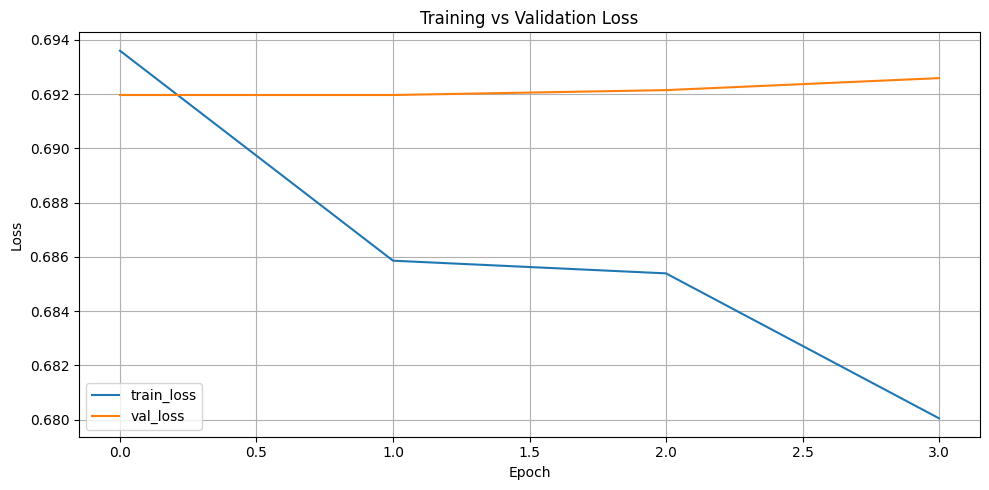

In [51]:
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Training and Validation Accuracy**

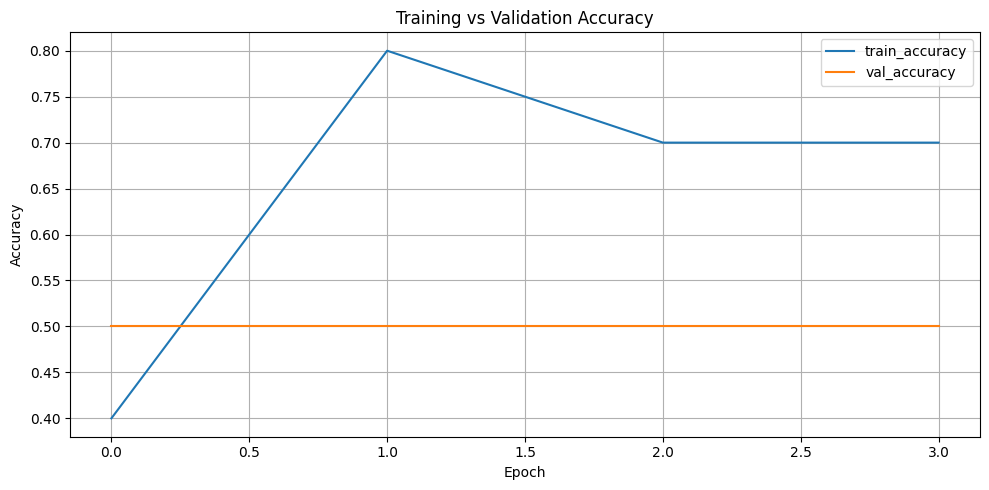

In [52]:
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### **Evaluate on the Test Set**

In [53]:
test_loss, test_accuracy = model.evaluate([X_q1_test, X_q2_test], y_test, verbose=0)
print({"test_loss": round(float(test_loss), 4), "test_accuracy": round(float(test_accuracy), 4)})

{'test_loss': 0.6858, 'test_accuracy': 0.6667}


### **Generate Test Predictions**

In [54]:
y_pred_prob = model.predict([X_q1_test, X_q2_test], verbose=0).reshape(-1)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(y_pred[:10])
print(y_pred_prob[:10])

[1 1 1]
[0.51161504 0.5110182  0.5111953 ]


### **Compute Precision, Recall, and F1**

In [55]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="binary",
    zero_division=0
)

metrics_dict = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}
metrics_dict

{'accuracy': 0.6666666666666666,
 'precision': 0.6666666666666666,
 'recall': 1.0,
 'f1_score': 0.8}

### **Display Classification Report**

In [56]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



### **Create Confusion Matrix Table**

In [57]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
cm_df

,Pred 0,Pred 1
Actual 0,0,1
Actual 1,0,2


### **Visualize Confusion Matrix**

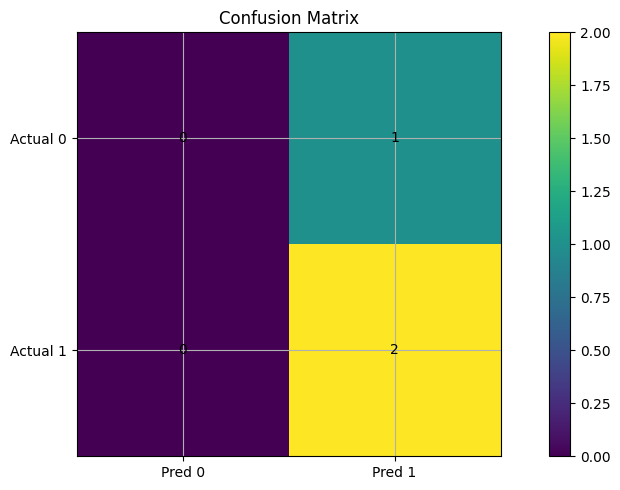

In [58]:
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### **Create Prediction Analysis DataFrame**

In [59]:
prediction_df = test_meta_df.copy().reset_index(drop=True)
prediction_df["true_label"] = y_test
prediction_df["pred_prob"] = y_pred_prob
prediction_df["pred_label"] = y_pred
prediction_df["is_correct"] = (prediction_df["true_label"] == prediction_df["pred_label"]).astype(int)
prediction_df["confidence"] = np.where(
    prediction_df["pred_label"] == 1,
    prediction_df["pred_prob"],
    1 - prediction_df["pred_prob"]
)
prediction_df.head()

,question1,question2,is_duplicate,q1_char_len,q1_word_len,q2_char_len,q2_word_len,q1_clean,q2_clean,q1_seq,q2_seq,true_label,pred_prob,pred_label,is_correct,confidence
0,How to improve English speaking skills?,How can I speak English fluently?,1,39,6,33,6,how to improve english speaking skills,how can i speak english fluently,"[2, 5, 31, 10, 32, 33]","[2, 7, 4, 57, 10, 58]",1,0.511615,1,1,0.511615
1,What are symptoms of heart attack?,What are the warning signs of a heart attack?,1,34,6,45,9,what are symptoms of heart attack,what are the warning signs of a heart attack,"[3, 24, 45, 25, 36, 37]","[3, 24, 9, 61, 62, 25, 42, 36, 37]",1,0.511018,1,1,0.511018
2,How can I learn python quickly?,What is the capital of France?,0,31,6,30,6,how can i learn python quickly,what is the capital of france,"[2, 7, 4, 13, 14, 15]","[3, 6, 9, 67, 25, 68]",0,0.511195,1,0,0.511195


### **Review Most Confident Correct Predictions**

In [60]:
prediction_df.sort_values(["is_correct", "confidence"], ascending=[False, False]).head(10)

,question1,question2,is_duplicate,q1_char_len,q1_word_len,q2_char_len,q2_word_len,q1_clean,q2_clean,q1_seq,q2_seq,true_label,pred_prob,pred_label,is_correct,confidence
0,How to improve English speaking skills?,How can I speak English fluently?,1,39,6,33,6,how to improve english speaking skills,how can i speak english fluently,"[2, 5, 31, 10, 32, 33]","[2, 7, 4, 57, 10, 58]",1,0.511615,1,1,0.511615
1,What are symptoms of heart attack?,What are the warning signs of a heart attack?,1,34,6,45,9,what are symptoms of heart attack,what are the warning signs of a heart attack,"[3, 24, 45, 25, 36, 37]","[3, 24, 9, 61, 62, 25, 42, 36, 37]",1,0.511018,1,1,0.511018
2,How can I learn python quickly?,What is the capital of France?,0,31,6,30,6,how can i learn python quickly,what is the capital of france,"[2, 7, 4, 13, 14, 15]","[3, 6, 9, 67, 25, 68]",0,0.511195,1,0,0.511195


### **Review Most Confident Incorrect Predictions**

In [61]:
prediction_df.sort_values(["is_correct", "confidence"], ascending=[True, False]).head(10)

,question1,question2,is_duplicate,q1_char_len,q1_word_len,q2_char_len,q2_word_len,q1_clean,q2_clean,q1_seq,q2_seq,true_label,pred_prob,pred_label,is_correct,confidence
2,How can I learn python quickly?,What is the capital of France?,0,31,6,30,6,how can i learn python quickly,what is the capital of france,"[2, 7, 4, 13, 14, 15]","[3, 6, 9, 67, 25, 68]",0,0.511195,1,0,0.511195
0,How to improve English speaking skills?,How can I speak English fluently?,1,39,6,33,6,how to improve english speaking skills,how can i speak english fluently,"[2, 5, 31, 10, 32, 33]","[2, 7, 4, 57, 10, 58]",1,0.511615,1,1,0.511615
1,What are symptoms of heart attack?,What are the warning signs of a heart attack?,1,34,6,45,9,what are symptoms of heart attack,what are the warning signs of a heart attack,"[3, 24, 45, 25, 36, 37]","[3, 24, 9, 61, 62, 25, 42, 36, 37]",1,0.511018,1,1,0.511018


### **Analyze Errors by Duplicate Label**

In [62]:
prediction_df.groupby("true_label")["is_correct"].mean()

true_label
0    0.0
1    1.0
Name: is_correct, dtype: float64

### **Plot Prediction Confidence Distribution**

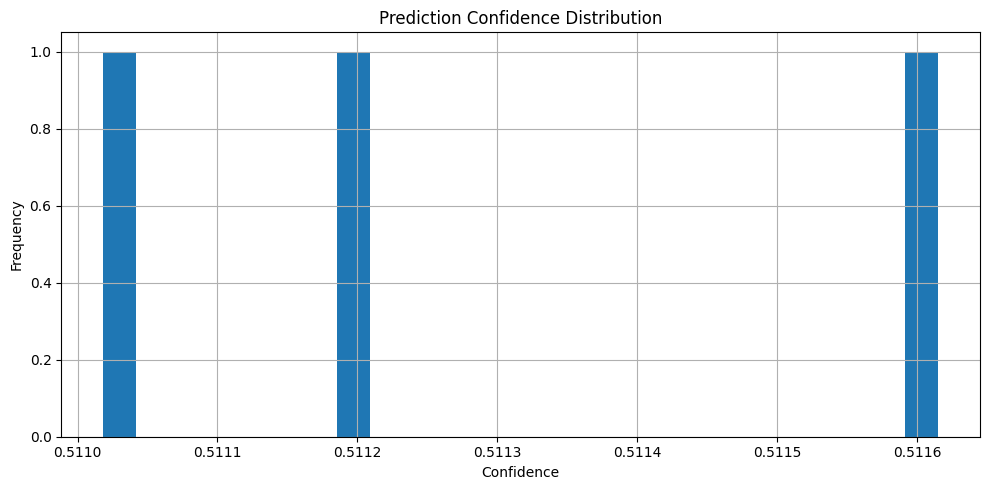

In [63]:
prediction_df["confidence"].hist(bins=25)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Create Shared Encoder Inference Model**

In [64]:
encoder_model = shared_encoder
print("Encoder model ready for pairwise similarity inspection.")

Encoder model ready for pairwise similarity inspection.


### **Build Sample Question Embeddings**

In [65]:
sample_q1_embeddings = encoder_model.predict(X_q1_test[:20], verbose=0)
sample_q2_embeddings = encoder_model.predict(X_q2_test[:20], verbose=0)

sample_q1_embeddings.shape, sample_q2_embeddings.shape

((3, 128), (3, 128))

### **Visualize Pairwise Cosine Similarity for Samples**

In [66]:
sample_similarities = np.diag(cosine_similarity(sample_q1_embeddings, sample_q2_embeddings))
pd.DataFrame({
    "question1": test_meta_df["q1_clean"].head(20).tolist(),
    "question2": test_meta_df["q2_clean"].head(20).tolist(),
    "true_label": y_test[:20],
    "pred_prob": y_pred_prob[:20],
    "pair_similarity": sample_similarities[:20]
}).head(10)

,question1,question2,true_label,pred_prob,pair_similarity
0,how to improve english speaking skills,how can i speak english fluently,1,0.511615,0.964158
1,what are symptoms of heart attack,what are the warning signs of a heart attack,1,0.511018,0.975322
2,how can i learn python quickly,what is the capital of france,0,0.511195,0.974257


### **Define Inference Utility**

In [67]:
def predict_question_pair(question1, question2):
    q1_clean = clean_text(question1)
    q2_clean = clean_text(question2)

    q1_seq = tokenizer.texts_to_sequences([q1_clean])
    q2_seq = tokenizer.texts_to_sequences([q2_clean])

    q1_pad = pad_sequences(q1_seq, maxlen=MAX_SEQ_LEN, padding="post", truncating="post")
    q2_pad = pad_sequences(q2_seq, maxlen=MAX_SEQ_LEN, padding="post", truncating="post")

    prob = float(model.predict([q1_pad, q2_pad], verbose=0).reshape(-1)[0])
    pred = int(prob >= 0.5)

    return {
        "duplicate_probability": prob,
        "predicted_duplicate": pred
    }

### **Test the Inference Utility**

In [68]:
predict_question_pair(
    "How can I learn python fast?",
    "What is the fastest way to learn python?"
)

{'duplicate_probability': 0.5127928853034973, 'predicted_duplicate': 1}

### **Create Sample Output Table**

In [69]:
sample_outputs = []
sample_rows = test_meta_df.head(min(5, len(test_meta_df)))

for _, row in sample_rows.iterrows():
    pred = predict_question_pair(row["q1_clean"], row["q2_clean"])
    sample_outputs.append({
        "question1": row["q1_clean"],
        "question2": row["q2_clean"],
        "predicted_duplicate": pred["predicted_duplicate"],
        "duplicate_probability": pred["duplicate_probability"]
    })

pd.DataFrame(sample_outputs)

,question1,question2,predicted_duplicate,duplicate_probability
0,how to improve english speaking skills,how can i speak english fluently,1,0.511615
1,what are symptoms of heart attack,what are the warning signs of a heart attack,1,0.511018
2,how can i learn python quickly,what is the capital of france,1,0.511195


### **Save Model Artifacts**

In [70]:
model.save(MODEL_DIR / "quora_duplicate_bilstm_siamese_model.keras")
with open(ARTIFACT_DIR / "tokenizer_config.json", "w", encoding="utf-8") as f:
    json.dump(tokenizer.to_json(), f)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


### **Save Prediction Outputs**

In [71]:
prediction_df.to_csv(PRED_DIR / "quora_duplicate_prediction_analysis.csv", index=False)
history_df.to_csv(PRED_DIR / "quora_duplicate_training_history.csv", index=False)

print("Prediction outputs saved.")

Prediction outputs saved.


### **Reload the Saved Model**

In [72]:
def pairwise_output_shape(input_shapes):
    return input_shapes[0]

print("Similarity Lambda layers were already created before model construction.")

Similarity Lambda layers were already created before model construction.


### **Run Reload Validation**

In [73]:
@tf.keras.utils.register_keras_serializable(package="Custom")
def abs_diff_fn(tensors):
    return tf.abs(tensors[0] - tensors[1])

@tf.keras.utils.register_keras_serializable(package="Custom")
def multiply_fn(tensors):
    return tensors[0] * tensors[1]

def pairwise_output_shape(input_shapes):
    return input_shapes[0]

reloaded_model = tf.keras.models.load_model(
    MODEL_DIR / "quora_duplicate_bilstm_siamese_model.keras",
    custom_objects={
        "abs_diff_fn": abs_diff_fn,
        "multiply_fn": multiply_fn,
        "pairwise_output_shape": pairwise_output_shape,
    },
    safe_mode=False
)

print("Reloaded model successfully.")

Reloaded model successfully.


### **Create Deployment Demo Function**

In [74]:
def duplicate_question_demo(question1, question2):
    return predict_question_pair(question1, question2)

### **Test Deployment Demo Function**

In [75]:
duplicate_question_demo(
    "What is machine learning?",
    "Can you explain machine learning?"
)

{'duplicate_probability': 0.510392963886261, 'predicted_duplicate': 1}

### **Create Optional Streamlit App Code**

In [76]:
streamlit_app_code = '''
import streamlit as st

st.title("Question Duplicate Detection Demo")
q1 = st.text_area("Question 1")
q2 = st.text_area("Question 2")

if st.button("Check Similarity"):
    st.write("Load the saved model and display duplicate probability here.")
'''
print(streamlit_app_code)


import streamlit as st

st.title("Question Duplicate Detection Demo")
q1 = st.text_area("Question 1")
q2 = st.text_area("Question 2")

if st.button("Check Similarity"):
    st.write("Load the saved model and display duplicate probability here.")



### **Final Project Summary for Notebook Report**

In [77]:
final_project_notes = {
    "project_title": "Question Answer Matching System using Bi-Directional LSTM Siamese Network",
    "dataset": "Quora Question Pairs",
    "model_type": "BiLSTM Siamese Network",
    "core_goal": "Detect semantic duplicates between question pairs using contextual sequence modeling.",
    "deployment_ready": True,
    "includes_demo": True
}
final_project_notes

{'project_title': 'Question Answer Matching System using Bi-Directional LSTM Siamese Network',
 'dataset': 'Quora Question Pairs',
 'model_type': 'BiLSTM Siamese Network',
 'core_goal': 'Detect semantic duplicates between question pairs using contextual sequence modeling.',
 'deployment_ready': True,
 'includes_demo': True}

### **Conclusion**

In [78]:
print(
    "This notebook built an end-to-end Siamese BiLSTM semantic similarity workflow with dataset analysis, "
    "shared tokenization, sequence preprocessing, duplicate classification, pairwise similarity inspection, "
    "evaluation, error analysis, and an optional deployment demo."
)

This notebook built an end-to-end Siamese BiLSTM semantic similarity workflow with dataset analysis, shared tokenization, sequence preprocessing, duplicate classification, pairwise similarity inspection, evaluation, error analysis, and an optional deployment demo.
